In [2]:
# ── DAY 12 | BASELINE MODELS ──
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
# ── STEP 2: Load dataset ──
df = pd.read_csv(r'D:\Python project\data\European_Bank_Segmented.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{list(df.columns)}")
print(f"\nChurn rate: {df['Exited'].mean()*100:.2f}%")

Shape: (10000, 21)

Columns:
['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'AgeGroup', 'CreditBand', 'TenureGroup', 'BalanceSegment', 'CLV_Score', 'CLV_Segment', 'EngagementScore', 'Balance_Salary_Ratio', 'Cluster', 'Persona']

Churn rate: 20.37%


In [4]:
# ── STEP 3: Prepare features ──
# Drop target, leakage, redundant columns
drop_cols = ['Exited', 'Cluster', 'Persona',
             'AgeGroup', 'CreditBand', 'TenureGroup',
             'BalanceSegment', 'CLV_Segment']

X = df.drop(columns=drop_cols)
y = df['Exited']

# Encode Gender
X['Gender'] = X['Gender'].map({'Male': 0, 'Female': 1})

# One-Hot Encode Geography
X = pd.get_dummies(X, columns=['Geography'], drop_first=False)

print(f"Features shape: {X.shape}")
print(f"\nFeature columns:\n{list(X.columns)}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Features shape: (10000, 15)

Feature columns:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'CLV_Score', 'EngagementScore', 'Balance_Salary_Ratio', 'Geography_France', 'Geography_Germany', 'Geography_Spain']

Target distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64


In [5]:
# ── STEP 4: Train/Test Split ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nTraining churn rate: {y_train.mean()*100:.2f}%")
print(f"Test churn rate:     {y_test.mean()*100:.2f}%")

Training set: (8000, 15)
Test set:     (2000, 15)

Training churn rate: 20.38%
Test churn rate:     20.35%


In [6]:
# ── STEP 5: Apply SMOTE ──
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {X_train.shape[0]} samples")
print(f"After SMOTE:  {X_train_bal.shape[0]} samples")
print(f"\nClass distribution after SMOTE:")
print(pd.Series(y_train_bal).value_counts())
print(f"\nNew churn rate: {y_train_bal.mean()*100:.2f}%")

Before SMOTE: 8000 samples
After SMOTE:  12740 samples

Class distribution after SMOTE:
Exited
1    6370
0    6370
Name: count, dtype: int64

New churn rate: 50.00%


In [7]:
# ── STEP 6: Train Logistic Regression ──
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_bal, y_train_bal)

y_pred_lr = lr_model.predict(X_test)

print("LOGISTIC REGRESSION RESULTS")
print("="*45)
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1593
           1       0.39      0.40      0.39       407

    accuracy                           0.75      2000
   macro avg       0.62      0.62      0.62      2000
weighted avg       0.75      0.75      0.75      2000



In [8]:
# ── STEP 6: Train Logistic Regression ──
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_bal, y_train_bal)

y_pred_lr = lr_model.predict(X_test)

print("LOGISTIC REGRESSION RESULTS")
print("="*45)
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1593
           1       0.39      0.40      0.39       407

    accuracy                           0.75      2000
   macro avg       0.62      0.62      0.62      2000
weighted avg       0.75      0.75      0.75      2000



In [9]:
# ── STEP 7: Train Decision Tree ──
dt_model = DecisionTreeClassifier(random_state=42, max_depth=5)
dt_model.fit(X_train_bal, y_train_bal)

y_pred_dt = dt_model.predict(X_test)

print("DECISION TREE RESULTS")
print("="*45)
print(classification_report(y_test, y_pred_dt))

DECISION TREE RESULTS
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      1593
           1       0.47      0.64      0.54       407

    accuracy                           0.78      2000
   macro avg       0.68      0.73      0.70      2000
weighted avg       0.81      0.78      0.79      2000



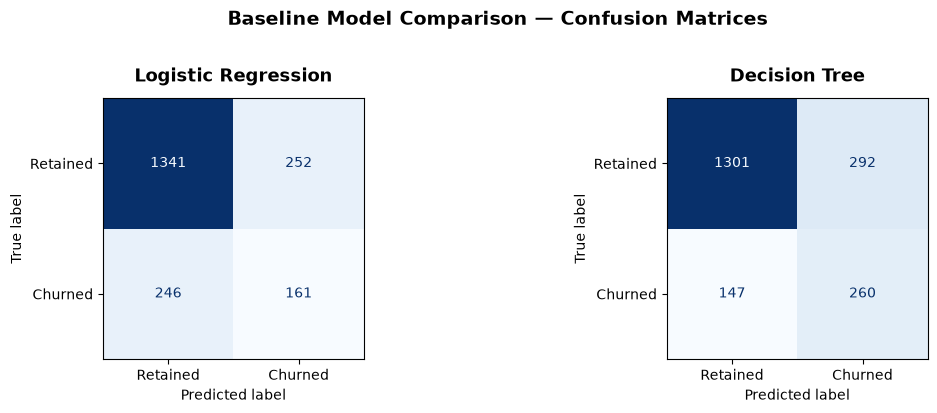

Chart saved!


In [10]:
# ── STEP 8: Confusion Matrix Visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = [
    (y_pred_lr, 'Logistic Regression'),
    (y_pred_dt, 'Decision Tree')
]

for ax, (y_pred, title) in zip(axes, models):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

plt.suptitle('Baseline Model Comparison — Confusion Matrices',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\23_baseline_confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

DAY 13 : Advanced Models + Model Selection

In [11]:
# ── DAY 13 | STEP 1: Random Forest ──
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=10
)
rf_model.fit(X_train_bal, y_train_bal)

y_pred_rf = rf_model.predict(X_test)

print("RANDOM FOREST RESULTS")
print("="*45)
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1593
           1       0.59      0.64      0.61       407

    accuracy                           0.83      2000
   macro avg       0.75      0.76      0.75      2000
weighted avg       0.84      0.83      0.84      2000



In [12]:
# ── DAY 13 | STEP 2: XGBoost ──
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb_model.fit(X_train_bal, y_train_bal)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBOOST RESULTS")
print("="*45)
print(classification_report(y_test, y_pred_xgb))

XGBOOST RESULTS
              precision    recall  f1-score   support

           0       0.89      0.90      0.90      1593
           1       0.61      0.58      0.59       407

    accuracy                           0.84      2000
   macro avg       0.75      0.74      0.75      2000
weighted avg       0.84      0.84      0.84      2000



In [13]:
# ── STEP 3: Model Comparison Summary ──
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 
              'Random Forest', 'XGBoost'],
    'Accuracy': [0.75, 0.78, 0.83, 0.84],
    'Precision': [0.39, 0.47, 0.59, 0.61],
    'Recall': [0.40, 0.64, 0.64, 0.58],
    'F1_Score': [0.39, 0.54, 0.61, 0.59]
}

results_df = pd.DataFrame(results)
results_df = results_df.set_index('Model')
print("MODEL COMPARISON — CHURN CLASS (1) METRICS")
print("="*55)
print(results_df.to_string())

MODEL COMPARISON — CHURN CLASS (1) METRICS
                     Accuracy  Precision  Recall  F1_Score
Model                                                     
Logistic Regression      0.75       0.39    0.40      0.39
Decision Tree            0.78       0.47    0.64      0.54
Random Forest            0.83       0.59    0.64      0.61
XGBoost                  0.84       0.61    0.58      0.59


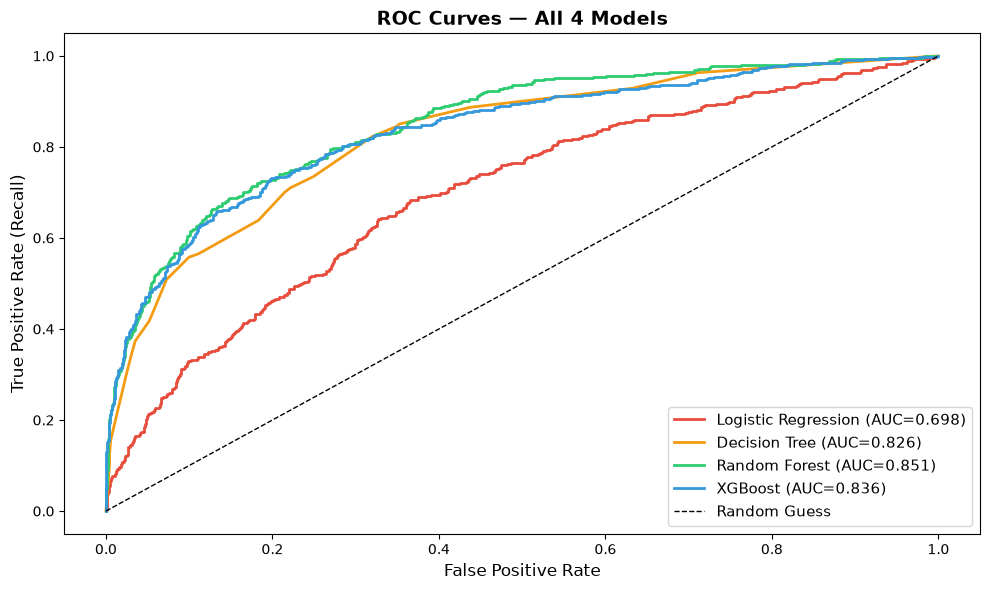

ROC curves saved!


In [14]:
# ── STEP 4: ROC Curves ──
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(10, 6))

models_roc = [
    (lr_model,  X_test, 'Logistic Regression', '#e74c3c'),
    (dt_model,  X_test, 'Decision Tree',        '#f39c12'),
    (rf_model,  X_test, 'Random Forest',        '#2ecc71'),
    (xgb_model, X_test, 'XGBoost',              '#3498db')
]

for model, X, name, color in models_roc:
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
             color=color, linewidth=2)

plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves — All 4 Models', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(r'D:\Python project\reports\24_roc_curves.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("ROC curves saved!")

Day 14 : GridSearch CV

In [15]:
# ── DAY 14 | STEP 1: GridSearchCV — Random Forest ──
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth':    [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_bal, y_train_bal)

print(f"\nBest Parameters: {grid_rf.best_params_}")
print(f"Best CV Recall:  {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best Parameters: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Recall:  0.8812


In [16]:
# ── STEP 2: Evaluate Tuned Random Forest ──
best_rf = grid_rf.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)

print("TUNED RANDOM FOREST RESULTS")
print("="*45)
print(classification_report(y_test, y_pred_best_rf))

TUNED RANDOM FOREST RESULTS
              precision    recall  f1-score   support

           0       0.90      0.91      0.90      1593
           1       0.63      0.61      0.62       407

    accuracy                           0.85      2000
   macro avg       0.76      0.76      0.76      2000
weighted avg       0.84      0.85      0.85      2000



In [17]:
# ── STEP 3: GridSearchCV — XGBoost ──
from sklearn.model_selection import GridSearchCV

param_grid_xgb = {
    'n_estimators':  [100, 200],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

grid_xgb = GridSearchCV(
    XGBClassifier(random_state=42,
                  eval_metric='logloss',
                  verbosity=0),
    param_grid_xgb,
    cv=5,
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

grid_xgb.fit(X_train_bal, y_train_bal)

print(f"\nBest Parameters: {grid_xgb.best_params_}")
print(f"Best CV Recall:  {grid_xgb.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best CV Recall:  0.8669


In [18]:
# ── STEP 4: Evaluate Tuned XGBoost ──
best_xgb = grid_xgb.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test)

print("TUNED XGBOOST RESULTS")
print("="*45)
print(classification_report(y_test, y_pred_best_xgb))

TUNED XGBOOST RESULTS
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      1593
           1       0.59      0.57      0.58       407

    accuracy                           0.83      2000
   macro avg       0.74      0.73      0.74      2000
weighted avg       0.83      0.83      0.83      2000



In [19]:
# ── STEP 5: Final Model Comparison ──
final_results = {
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost',
        'Tuned Random Forest',
        'Tuned XGBoost'
    ],
    'Recall':     [0.40, 0.64, 0.64, 0.58, 0.61, 0.57],
    'Precision':  [0.39, 0.47, 0.59, 0.61, 0.63, 0.59],
    'F1_Score':   [0.39, 0.54, 0.61, 0.59, 0.62, 0.58],
    'Accuracy':   [0.75, 0.78, 0.83, 0.84, 0.85, 0.83]
}

final_df = pd.DataFrame(final_results).set_index('Model')
print("COMPLETE MODEL COMPARISON")
print("="*60)
print(final_df.to_string())
print("\n✅ Selected Model: Random Forest (balanced recall + precision)")

COMPLETE MODEL COMPARISON
                     Recall  Precision  F1_Score  Accuracy
Model                                                     
Logistic Regression    0.40       0.39      0.39      0.75
Decision Tree          0.64       0.47      0.54      0.78
Random Forest          0.64       0.59      0.61      0.83
XGBoost                0.58       0.61      0.59      0.84
Tuned Random Forest    0.61       0.63      0.62      0.85
Tuned XGBoost          0.57       0.59      0.58      0.83

✅ Selected Model: Random Forest (balanced recall + precision)
